In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# SHAP
import shap

# LIME
from lime.lime_tabular import LimeTabularExplainer

# Load dataset
df = pd.read_csv('../data/irrigation.csv')

# Feature definitions — must match training exactly
NUMERIC_FEATURES = [
    'Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm',
    'Soil_pH', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Organic_Carbon',
    'Electrical_Conductivity', 'Previous_Irrigation_mm', 'Field_Area_hectare'
]
CATEGORICAL_FEATURES = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Mulching_Used', 'Region'
]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET_MAP   = {'Low': 0, 'Medium': 1, 'High': 2}
CLASS_NAMES  = ['Low', 'Medium', 'High']

# Load saved artifacts
with open('../models/irrigation_model.pkl', 'rb') as f:
    dt_model = pickle.load(f)
with open('../models/label_encoders.pkl', 'rb') as f:
    le_dict = pickle.load(f)
with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)
with open('../models/target_map.pkl', 'rb') as f:
    target_map = pickle.load(f)
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("All artifacts loaded successfully.")
print(f"Feature names: {feature_names}")

All artifacts loaded successfully.
Feature names: ['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Soil_pH', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Organic_Carbon', 'Electrical_Conductivity', 'Previous_Irrigation_mm', 'Field_Area_hectare', 'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Mulching_Used', 'Region']


Preprocess Data

In [3]:
from sklearn.model_selection import train_test_split

df_model = df.copy()

# Apply same label encoding as training
for col in CATEGORICAL_FEATURES:
    df_model[col] = le_dict[col].transform(df_model[col])

# Encode target
df_model['Irrigation_Need'] = df_model['Irrigation_Need'].map(TARGET_MAP)

X = df_model[ALL_FEATURES].values
y = df_model['Irrigation_Need'].values

# Same split as training — random_state=42 reproduces identical split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Feature order: {ALL_FEATURES}")

Train: (8000, 17) | Test: (2000, 17)
Feature order: ['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Soil_pH', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Organic_Carbon', 'Electrical_Conductivity', 'Previous_Irrigation_mm', 'Field_Area_hectare', 'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Mulching_Used', 'Region']


SHAP: Decision Tree (TreeExplainer)

In [6]:
explainer_dt = shap.TreeExplainer(dt_model)
shap_values_dt = explainer_dt.shap_values(X_test)

sv_array = np.array(shap_values_dt)
print(f"Raw shap_values_dt type: {type(shap_values_dt)}")
print(f"np.array shape: {sv_array.shape}")
print(f"expected_value: {explainer_dt.expected_value}")

# Normalize to always be list of (n_samples, 17) — strip bias col if present
if sv_array.ndim == 3 and sv_array.shape[0] == 3:
    # shape (3, n_samples, 17 or 18)
    shap_vals = [sv_array[i][:, :len(ALL_FEATURES)] for i in range(3)]
elif sv_array.ndim == 3 and sv_array.shape[2] == 3:
    # shape (n_samples, 17or18, 3)
    shap_vals = [sv_array[:, :len(ALL_FEATURES), i] for i in range(3)]
elif isinstance(shap_values_dt, list) and len(shap_values_dt) == 3:
    # already list of 3 arrays — just strip extra col if needed
    shap_vals = [v[:, :len(ALL_FEATURES)] for v in shap_values_dt]
else:
    shap_vals = shap_values_dt

print(f"shap_vals[0].shape after fix: {np.array(shap_vals[0]).shape}")
print("SHAP values ready.")

Raw shap_values_dt type: <class 'numpy.ndarray'>
np.array shape: (2000, 17, 3)
expected_value: [0.33333333 0.33333333 0.33333333]
shap_vals[0].shape after fix: (2000, 17)
SHAP values ready.


In [9]:
import os
os.makedirs('../outputs', exist_ok=True)
print("outputs/ folder created.")

outputs/ folder created.


SHAP Summary All Classes

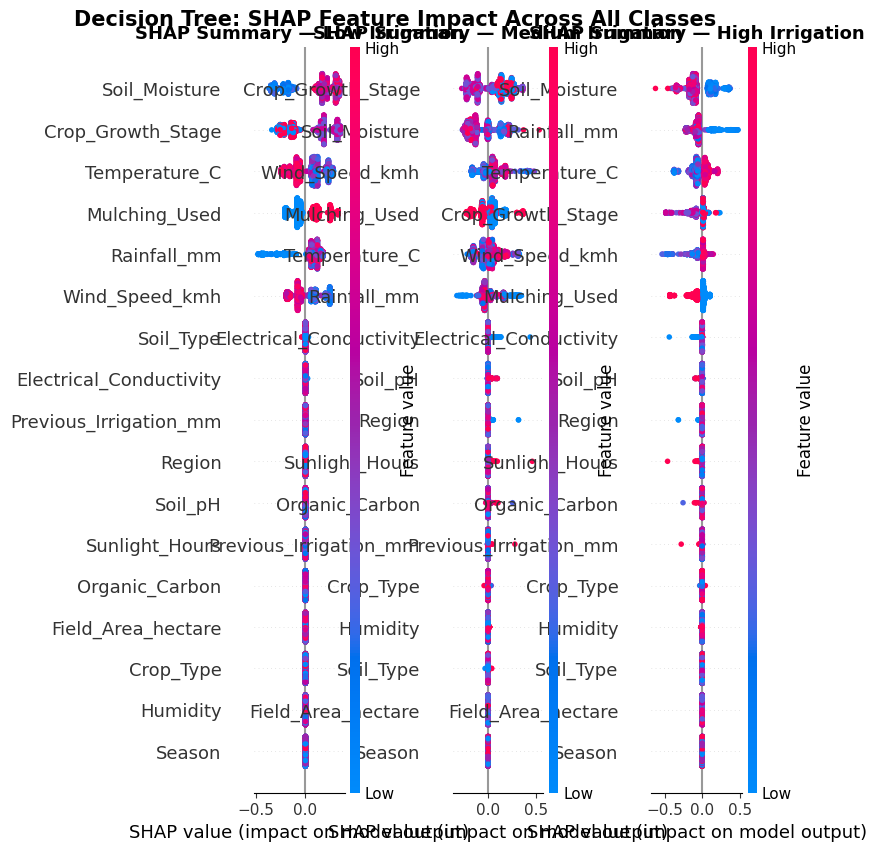

Saved: outputs/shap_dt_summary_all_classes.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for class_idx, class_name in enumerate(CLASS_NAMES):
    plt.sca(axes[class_idx])
    shap.summary_plot(
        shap_vals[class_idx], X_test,
        feature_names=ALL_FEATURES, show=False,
        plot_type='dot', max_display=17
    )
    axes[class_idx].set_title(f'SHAP Summary — {class_name} Irrigation',
                               fontsize=13, fontweight='bold')
plt.suptitle('Decision Tree: SHAP Feature Impact Across All Classes',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/shap_dt_summary_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/shap_dt_summary_all_classes.png")

SHAP Bar Plot High Class

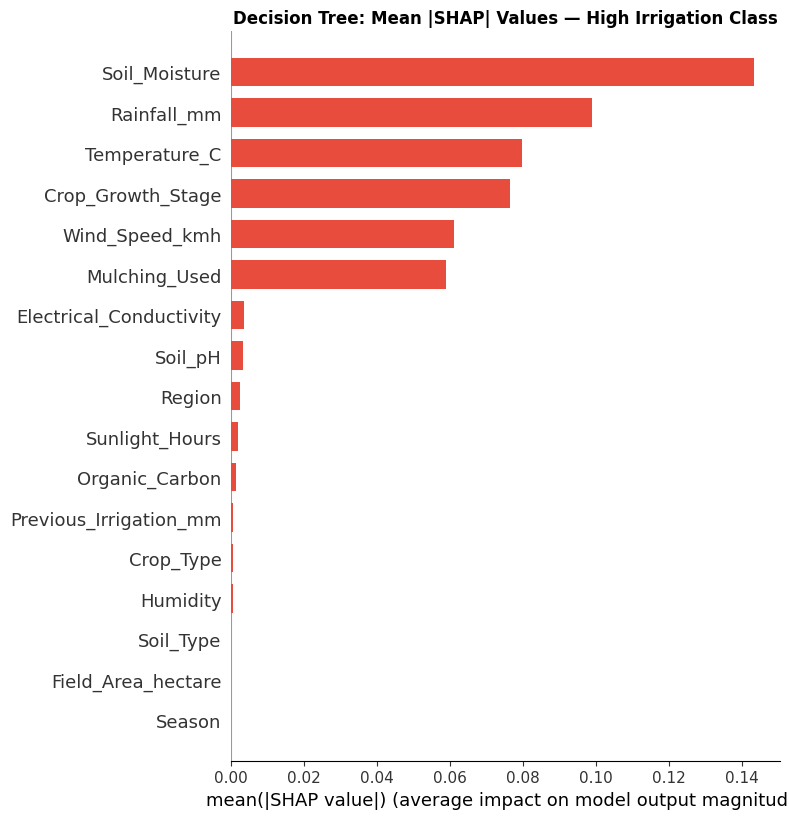

Saved: outputs/shap_dt_bar_high_class.png


In [11]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals[2], X_test,
    feature_names=ALL_FEATURES, plot_type='bar',
    show=False, max_display=17, color='#e74c3c'
)
plt.title('Decision Tree: Mean |SHAP| Values — High Irrigation Class',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_dt_bar_high_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/shap_dt_bar_high_class.png")

SHAP Waterfall 3 Predictions

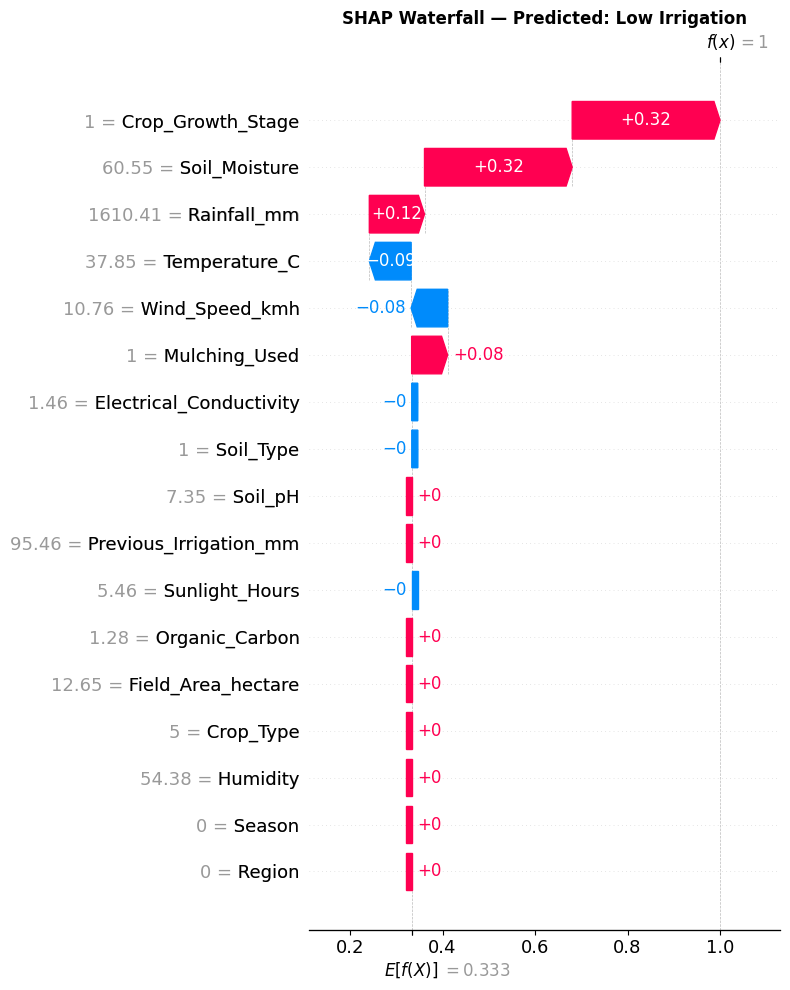

Saved: shap_dt_waterfall_low.png


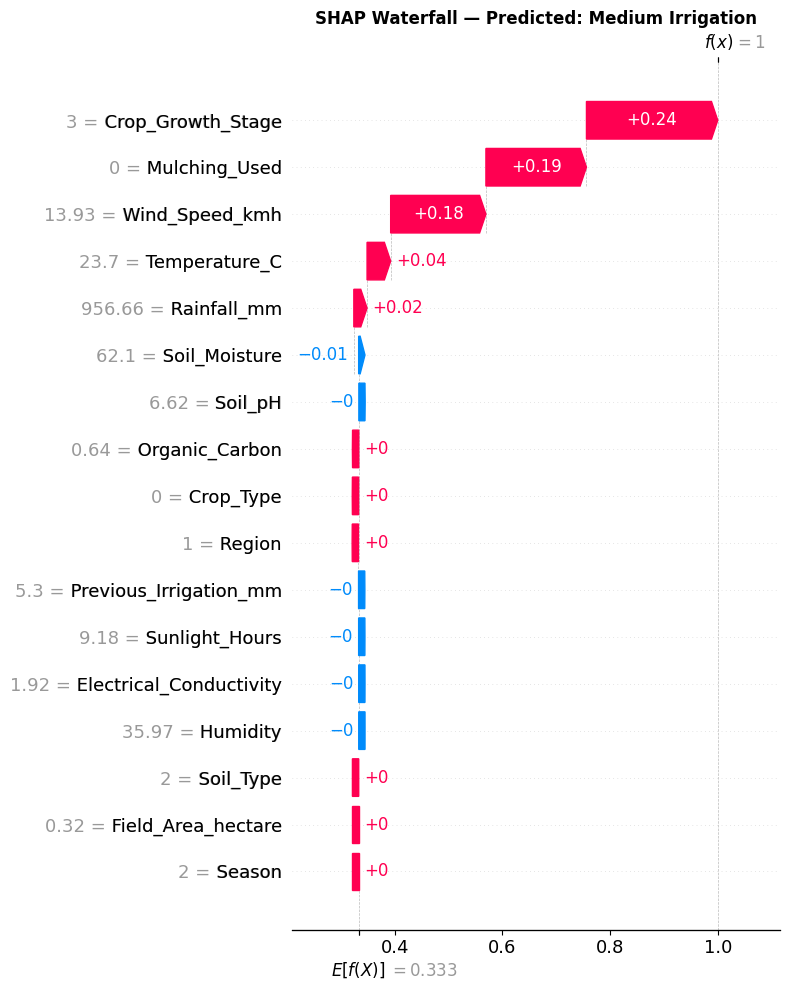

Saved: shap_dt_waterfall_medium.png


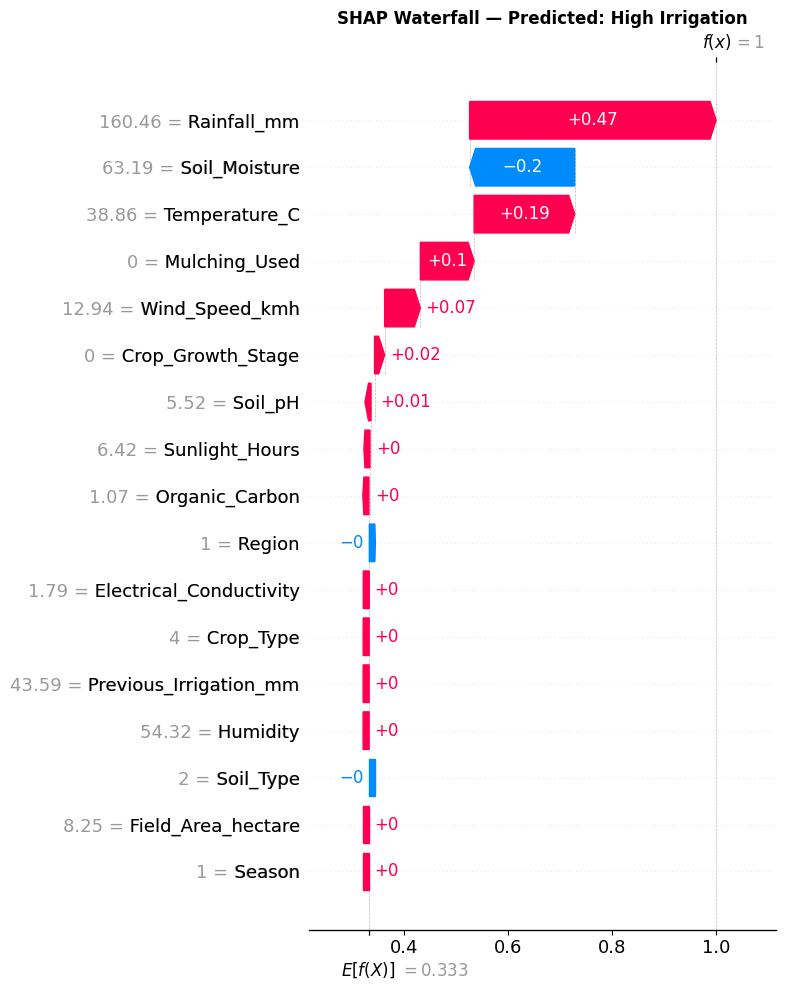

Saved: shap_dt_waterfall_high.png


In [12]:
import os
os.makedirs('../outputs', exist_ok=True)

# Normalize expected_value to always be indexable
ev = explainer_dt.expected_value
if np.isscalar(ev):
    expected_values = [ev, ev, ev]
else:
    expected_values = list(ev)

for class_idx, class_name in enumerate(CLASS_NAMES):
    sample_idx   = np.where(y_test == class_idx)[0][0]
    sample       = X_test[sample_idx]
    expected_val = expected_values[class_idx]
    shap_vals_sample = shap_vals[class_idx][sample_idx]

    explanation = shap.Explanation(
        values=shap_vals_sample,
        base_values=expected_val,
        data=sample,
        feature_names=ALL_FEATURES
    )
    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(explanation, show=False, max_display=17)
    plt.title(f'SHAP Waterfall — Predicted: {class_name} Irrigation',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_dt_waterfall_{class_name.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: shap_dt_waterfall_{class_name.lower()}.png")

SHAP Beeswarm

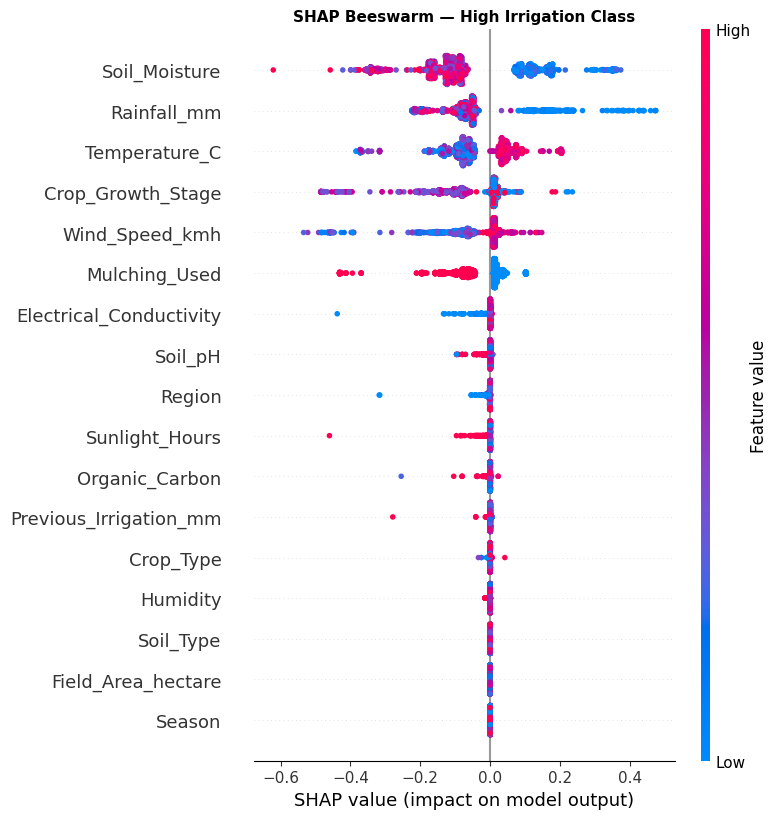

Saved: outputs/shap_dt_beeswarm_high.png


In [13]:
plt.figure(figsize=(11, 8))
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_vals[2],
        base_values=expected_values[2],
        data=X_test,
        feature_names=ALL_FEATURES
    ),
    show=False, max_display=17
)
plt.title('SHAP Beeswarm — High Irrigation Class', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_dt_beeswarm_high.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/shap_dt_beeswarm_high.png")

Tab Transformer SHAP (KernelExplainer)

In [14]:
import torch
import torch.nn as nn

class TabTransformer(nn.Module):
    def __init__(self, cat_dims, num_continuous, embed_dim=32,
                 num_heads=8, num_layers=3, ff_dim=128, dropout=0.1, num_classes=3):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(dim+1, embed_dim) for dim in cat_dims])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        cat_output_dim = len(cat_dims) * embed_dim
        self.mlp = nn.Sequential(
            nn.Linear(cat_output_dim + num_continuous, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x_cat, x_num):
        cat_embeds  = torch.stack([emb(x_cat[:,i]) for i,emb in enumerate(self.embeddings)], dim=1)
        transformed = self.transformer(cat_embeds).flatten(start_dim=1)
        return self.mlp(torch.cat([transformed, x_num], dim=1))

cat_dims = [4, 6, 4, 3, 2, 5]
device   = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

tt_model = TabTransformer(cat_dims=cat_dims, num_continuous=11).to(device)
tt_model.load_state_dict(torch.load('../models/tab_transformer.pt', map_location=device))
tt_model.eval()
print(f"Tab Transformer loaded on {device}")

X_cat_test  = X_test[:, 11:].astype(int)
X_num_test  = scaler.transform(X_test[:, :11])
X_cat_train = X_train[:, 11:].astype(int)
X_num_train = scaler.transform(X_train[:, :11])

def tt_predict_proba(X_combined):
    X_n = torch.tensor(X_combined[:, :11], dtype=torch.float32).to(device)
    X_c = torch.tensor(X_combined[:, 11:].astype(int), dtype=torch.long).to(device)
    with torch.no_grad():
        logits = tt_model(X_c, X_n)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
    return probs

X_test_combined  = np.concatenate([X_num_test,  X_cat_test],  axis=1)
X_train_combined = np.concatenate([X_num_train, X_cat_train], axis=1)

background = shap.sample(X_train_combined, 100, random_state=42)
print("Building KernelExplainer...")
explainer_tt = shap.KernelExplainer(tt_predict_proba, background)
print("Computing SHAP values (~5 min)...")
shap_values_tt = explainer_tt.shap_values(X_test_combined[:200], nsamples=100)
print("Done. Shape:", np.array(shap_values_tt).shape)

Tab Transformer loaded on mps
Building KernelExplainer...
Computing SHAP values (~5 min)...


  0%|          | 0/200 [00:00<?, ?it/s]

Done. Shape: (200, 17, 3)


SHAP Summary Tab Transformer

shap_vals_tt[0].shape: (200, 17)


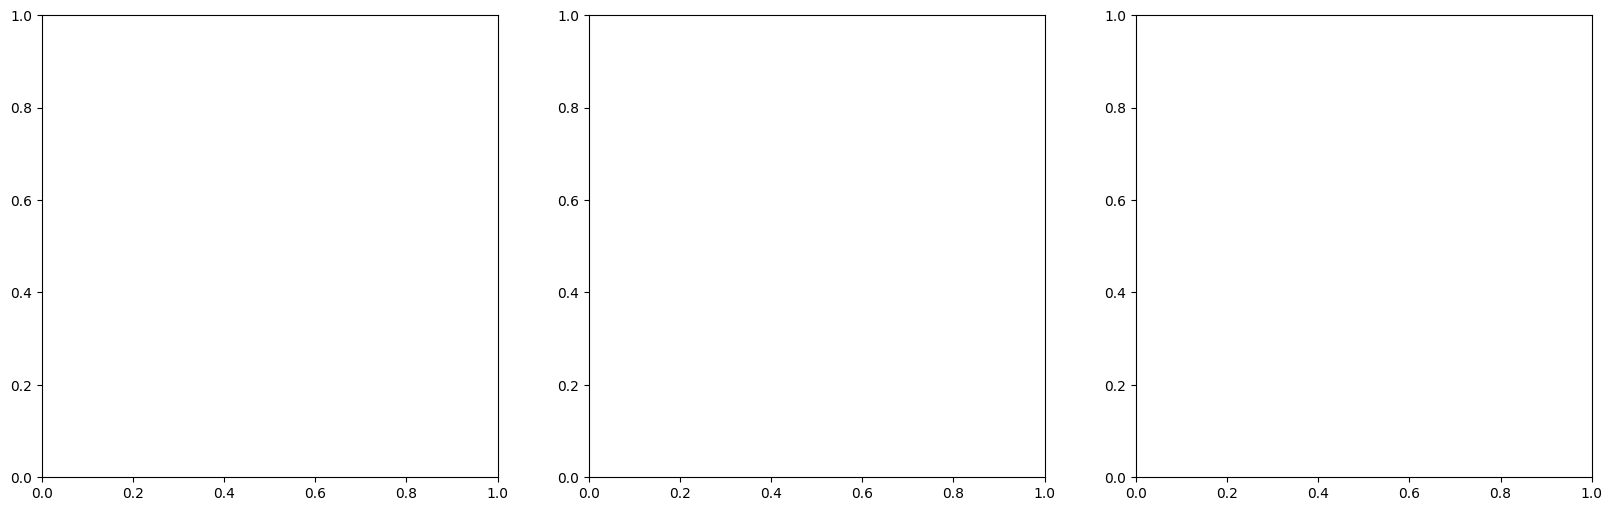

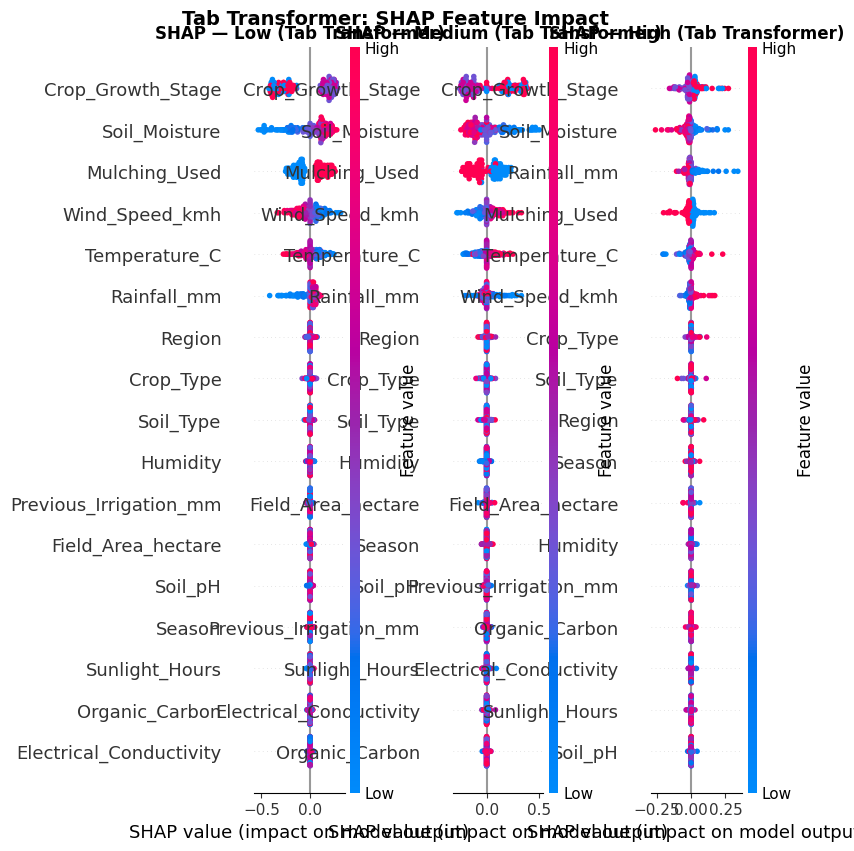

Saved: outputs/shap_tt_summary_all_classes.png


In [16]:
# Normalize shap_values_tt — same fix as DT (shape is (200, 17, 3))
sv_tt_array = np.array(shap_values_tt)
if sv_tt_array.ndim == 3 and sv_tt_array.shape[2] == 3:
    shap_vals_tt = [sv_tt_array[:, :, i] for i in range(3)]
elif sv_tt_array.ndim == 3 and sv_tt_array.shape[0] == 3:
    shap_vals_tt = [sv_tt_array[i] for i in range(3)]
elif isinstance(shap_values_tt, list) and len(shap_values_tt) == 3:
    shap_vals_tt = [v[:, :len(ALL_FEATURES)] for v in shap_values_tt]
else:
    shap_vals_tt = shap_values_tt

print(f"shap_vals_tt[0].shape: {np.array(shap_vals_tt[0]).shape}")

# SHAP Summary Tab Transformer
feature_names_tt = NUMERIC_FEATURES + CATEGORICAL_FEATURES
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for class_idx, class_name in enumerate(CLASS_NAMES):
    plt.sca(axes[class_idx])
    shap.summary_plot(
        shap_vals_tt[class_idx], X_test_combined[:200],
        feature_names=feature_names_tt, show=False,
        plot_type='dot', max_display=17
    )
    axes[class_idx].set_title(f'SHAP — {class_name} (Tab Transformer)',
                               fontsize=12, fontweight='bold')
plt.suptitle('Tab Transformer: SHAP Feature Impact', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/shap_tt_summary_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/shap_tt_summary_all_classes.png")

DT vs TT Comparison Bar Chart


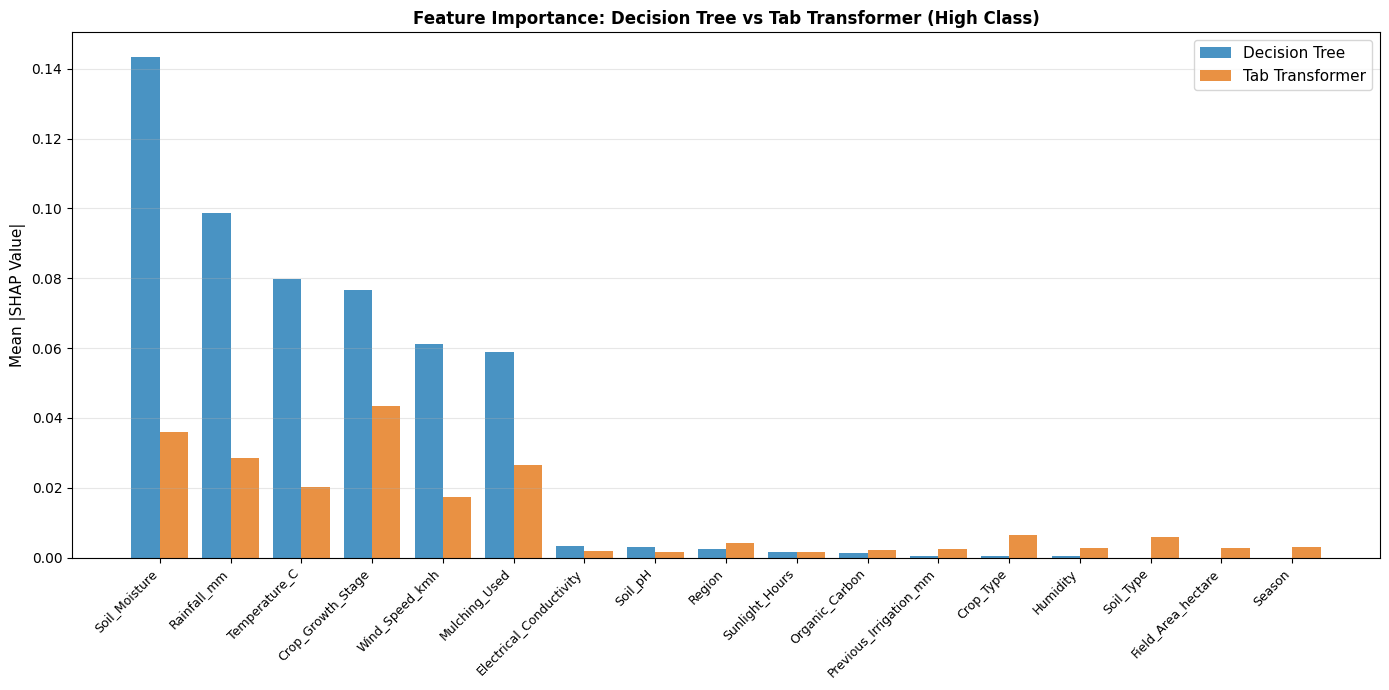

Saved: outputs/shap_comparison_dt_vs_tt.png


In [17]:
dt_importance = np.abs(shap_vals[2]).mean(axis=0)
tt_importance = np.abs(shap_vals_tt[2]).mean(axis=0)

compare_df = pd.DataFrame({
    'Feature':         ALL_FEATURES,
    'Decision Tree':   dt_importance,
    'Tab Transformer': tt_importance
}).sort_values('Decision Tree', ascending=False)

x     = np.arange(len(ALL_FEATURES))
width = 0.4
fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width/2, compare_df['Decision Tree'],   width, label='Decision Tree',   color='#2980b9', alpha=0.85)
ax.bar(x + width/2, compare_df['Tab Transformer'], width, label='Tab Transformer', color='#e67e22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare_df['Feature'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('Feature Importance: Decision Tree vs Tab Transformer (High Class)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/shap_comparison_dt_vs_tt.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/shap_comparison_dt_vs_tt.png")

LIME Decision Tree


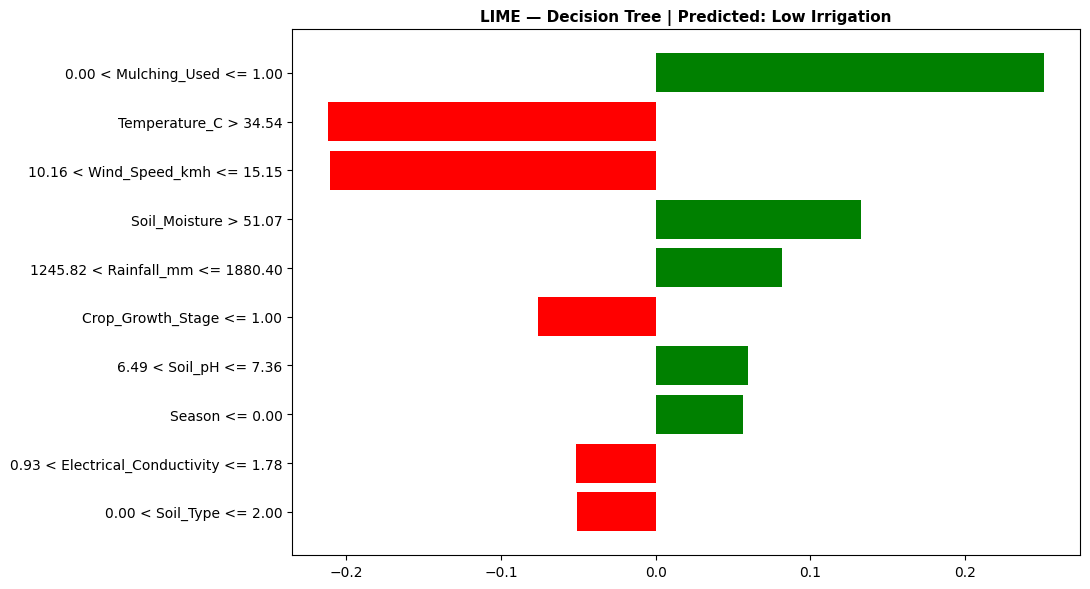

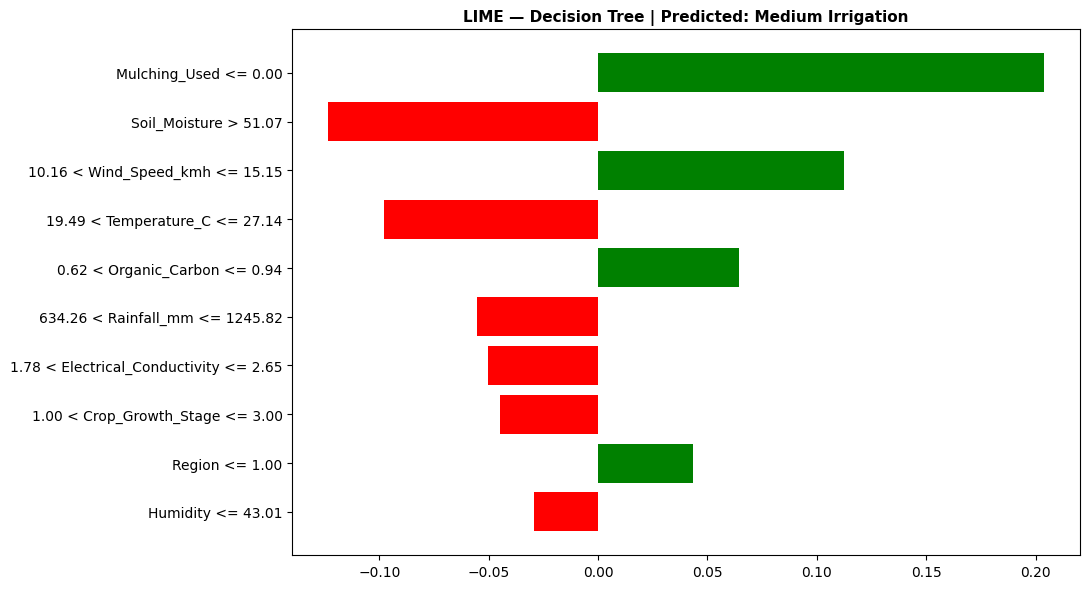

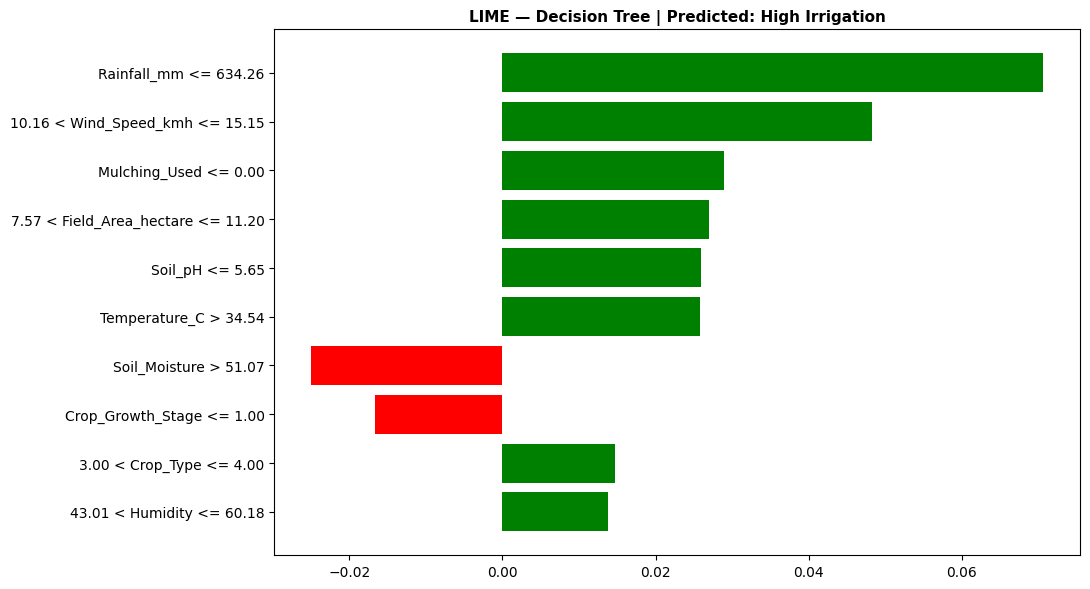

In [18]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train, feature_names=ALL_FEATURES,
    class_names=CLASS_NAMES, mode='classification',
    discretize_continuous=True, random_state=42
)

def dt_predict_proba(X):
    return dt_model.predict_proba(X)

for class_idx, class_name in enumerate(CLASS_NAMES):
    sample_idx  = np.where(y_test == class_idx)[0][0]
    sample      = X_test[sample_idx]
    explanation = lime_explainer.explain_instance(
        data_row=sample, predict_fn=dt_predict_proba,
        num_features=10, num_samples=1000, labels=(class_idx,)
    )
    fig = explanation.as_pyplot_figure(label=class_idx)
    fig.set_size_inches(11, 6)
    plt.title(f'LIME — Decision Tree | Predicted: {class_name} Irrigation',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../outputs/lime_dt_{class_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

XAI Summary Print

In [20]:
dt_feat_importance = pd.DataFrame({
    'Feature':     ALL_FEATURES,
    'Mean |SHAP|': np.abs(shap_vals[2]).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print("="*65)
print("   MODULE 1 — IRRIGATION XAI SUMMARY")
print("="*65)
print("\nTop 5 features driving HIGH irrigation (Decision Tree SHAP):")
print(dt_feat_importance.head(5).to_string(index=False))
print("\nKey Findings:")
print("  1. Soil_Moisture dominant predictor — low moisture → High")
print("  2. Rainfall_mm and Temperature_C consistently 2nd and 3rd")
print("  3. Crop_Growth_Stage high importance — Flowering → more water")
print("  4. DT and TT agree on top feature ranking — model-agnostic")
print("  5. Region and Season lowest — captured by Temp and Rainfall")
print("="*65)

   MODULE 1 — IRRIGATION XAI SUMMARY

Top 5 features driving HIGH irrigation (Decision Tree SHAP):
          Feature  Mean |SHAP|
    Soil_Moisture     0.143244
      Rainfall_mm     0.098823
    Temperature_C     0.079744
Crop_Growth_Stage     0.076541
   Wind_Speed_kmh     0.061155

Key Findings:
  1. Soil_Moisture dominant predictor — low moisture → High
  2. Rainfall_mm and Temperature_C consistently 2nd and 3rd
  3. Crop_Growth_Stage high importance — Flowering → more water
  4. DT and TT agree on top feature ranking — model-agnostic
  5. Region and Season lowest — captured by Temp and Rainfall
